In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from scipy.stats import linregress
import time
import os

In [9]:
def autocorrelation_fft(x, maxlag=None):
    """
    Compute the autocorrelation function using Fast Fourier Transform.
    
    This method is more efficient and numerically stable than direct computation,
    especially for long time series.
    
    Parameters
    ----------
    x : array-like
        Input time series data.
    maxlag : int, optional
        Maximum lag to compute. If None, uses len(x) - 1.
    
    Returns
    -------
    np.ndarray
        Normalized autocorrelation function from lag 0 to maxlag.
        ACF[k] = Cov(x[t], x[t+k]) / Var(x)
    
    Notes
    -----
    - Uses FFT convolution theorem: convolution in time = multiplication in frequency
    - Zero-pads to next power of 2 for optimal FFT performance
    - Returns 1.0 for all lags if variance is zero (constant series)
    """
    x = np.asarray(x, dtype=float)
    n = x.size
    if maxlag is None:
        maxlag = n - 1
    
    # Center the data by subtracting mean
    mean = x.mean()
    x = x - mean
    
    # Find next power of 2 for efficient FFT (zero-padding)
    m = 1 << (int(np.log2(2*n - 1)) + 1)
    
    # Compute autocorrelation via FFT: AC = IFFT(|FFT(x)|^2)
    fx = np.fft.rfft(x, n=m)
    acfull = np.fft.irfft(fx * np.conjugate(fx), n=m)[:n]
    acfull = acfull / n  # Normalize by length
    
    # Normalize by variance to get correlation
    var = x.var()
    if var == 0:
        return np.ones(maxlag+1)  # Constant series has ACF = 1 everywhere
    
    ac = acfull[:maxlag+1] / var
    return ac


def integrated_tau_from_ac(ac, c_factor=5, max_iter=200, tau=None):
    """
    Compute integrated autocorrelation time using self-consistent windowing.
    
    Implements Sokal's automatic windowing method where the integration window
    depends on the autocorrelation time itself, solved iteratively.
    
    Parameters
    ----------
    ac : np.ndarray
        Autocorrelation function values.
    c_factor : float, default 5
        Window multiplier: W = c_factor * tau. Typical values 3-6.
    max_iter : int, default 200
        Maximum iterations for convergence.
    tau : float, optional
        Initial guess for tau. If None, starts with 0.5.
    
    Returns
    -------
    float
        Integrated autocorrelation time τ_int.
        Returns np.inf if calculation fails.
    
    Notes
    -----
    Formula: τ_int = 1/2 + Σ(ACF[1:W])
    where W = c_factor * τ_int (solved self-consistently)
    
    Convergence: Iterates until |new_tau - tau| < 1e-6
    """
    if len(ac) < 2:
        return 0.5
    
    # Initialize tau with previous value or default
    if tau is None:
        tau = 0.5
    
    # Iterate to find self-consistent window
    for _ in range(max_iter):
        # Window size proportional to current tau estimate
        W = min(len(ac)-1, max(1, int(c_factor * tau)))
        
        # Compute new tau using current window
        new_tau = 0.5 + np.sum(ac[1:W+1])
        
        # Check validity
        if not np.isfinite(new_tau):
            return np.inf
        
        # Check convergence
        if abs(new_tau - tau) < 1e-6:
            return new_tau
        
        tau = new_tau
    
    return tau


def iterative_burn_and_tau(observable, c_factor=5, max_iter=10, min_fraction=0.001, verbose=False):
    """
    Automatically determine burn-in period and compute integrated autocorrelation time.
    
    Uses an iterative self-consistent approach:
    1. Estimate tau on current data
    2. Set burn-in = c_factor * tau
    3. Re-estimate tau on remaining data
    4. Repeat until burn-in stabilizes
    
    Parameters
    ----------
    observable : array-like
        Time series of observable (e.g., energy, magnetization).
    c_factor : float, default 3
        Multiplier for burn-in: burn = c_factor * tau.
        Also used for windowing in tau calculation.
    max_iter : int, default 10
        Maximum iterations for burn-in refinement.
    min_fraction : float, default 0.001
        Minimum fraction of data that must remain after burn-in (0.1%).
    verbose : bool, default False
        Print detailed iteration information.
    
    Returns
    -------
    burn : int
        Optimal burn-in index (number of initial points to discard).
    tau : float
        Integrated autocorrelation time of equilibrated data.
        Returns np.inf if estimation fails.
    ac : np.ndarray
        Final autocorrelation function of equilibrated data.
    
    Notes
    -----
    The algorithm handles three failure modes:
    1. Remaining series too short after burn-in
    2. Invalid tau (non-finite or non-positive)
    3. Burn-in exceeds total series length
    
    Final tau is more accurate than iteration values because:
    - Uses longer maxlag (up to 10M vs limited during iteration)
    - Computed on properly equilibrated data
    """
    n = len(observable)
    burn = 0  # Initial burn-in
    prev_burn = -1  # Previous iteration's burn-in
    tau = None  # Carries forward between iterations for faster convergence

    # Iteratively refine burn-in period
    for it in range(max_iter):
        # Extract data after current burn-in
        data = observable[burn:]
        
        # Check if enough data remains
        if len(data) < max(100, int(min_fraction * n)):
            if verbose:
                print(f"  [iter {it}] remaining series too short ({len(data)}), stopping.")
            break

        # Compute autocorrelation with limited maxlag for speed
        maxlag = min(len(data)-1, max(len(data)//10, 10000))
        ac = autocorrelation_fft(data, maxlag=maxlag)
        
        # Estimate tau (passes previous tau as initial guess)
        tau = integrated_tau_from_ac(ac, c_factor=c_factor, tau=tau)

        # Validate tau
        if not np.isfinite(tau) or tau <= 0:
            if verbose:
                print(f"  [iter {it}] invalid τ (tau={tau}), aborting iteration.")
            tau = np.inf
            break

        # Propose new burn-in based on tau
        new_burn = int(c_factor * tau)
        if verbose:
            print(f"  [iter {it}] len(data)={len(data)}, tau={tau:.3f}, new_burn={new_burn}")

        # Check if burn-in would exceed series length
        if new_burn >= len(observable):
            if verbose:
                print(f"  new_burn ({new_burn}) >= total series ({len(observable)}): abort.")
            burn = len(observable)
            tau = np.inf
            break

        # Check convergence: burn-in hasn't changed
        if new_burn == prev_burn:
            if verbose:
                print(f"  [convergence] burn-in stabilized at {burn}")
            burn = new_burn
            break

        # Update for next iteration
        prev_burn = new_burn
        burn = new_burn

    # Final validation: check if enough data remains
    data = observable[burn:]
    if len(data) < max(100, int(min_fraction * n)):
        if verbose:
            print(f"  Final: remaining series too short ({len(data)}). τ not computed.")
        return burn, np.inf, np.array([np.nan])

    # Final accurate computation with longer maxlag
    maxlag = len(data)//5
    ac = autocorrelation_fft(data, maxlag=maxlag)
    tau = integrated_tau_from_ac(ac, c_factor=c_factor, tau=tau)

    return burn, tau, ac

In [4]:
base_dir = "data/Metropolis_Temp_Scan_3_Million_Sweeps"
beta_c = 0.4407
h = 0.0

L_list = []
for folder in os.listdir(base_dir):
    m = re.match(r"L_(\d+)", folder)
    if m:
        L_list.append(int(m.group(1)))
L_list = sorted(L_list)
print("Detected sizes:", L_list)


Detected sizes: [2, 4, 8, 16, 32, 64, 128]


In [5]:
# replace data for L=2 with 600,000 sweeps
print(L_list)

[2, 4, 8, 16, 32, 64, 128]


In [11]:
# Storage for results: tau_vs_L[0] = magnetization, tau_vs_L[1] = energy
tau_vs_L = [[], []]
skipped = []  # Track which L values couldn't be processed

start_all = time.time()

# Process each lattice size
for L in L_list:
    print(f"\n===== Processing L = {L} =====")
    
    # Construct file path for this lattice size
    file_path = f"{base_dir}/L_{L}/h_{h}/mag_eng_beta_{beta_c:.4f}.npz"
    
    # Check if file exists
    if not os.path.exists(file_path):
        print(f"⚠️ Missing file: {file_path}")
        skipped.append((L, "missing file"))
        continue

    # Load simulation data
    data = np.load(file_path)
    
    # # Special case: use longer simulation (10M sweeps) for L=128
    # # This ensures sufficient statistics for the largest system size
    # if L == 128:
    #     alt_dir = "data/Metropolis_Temp_Scan_10_Million_Sweeps"
    #     alt_path = f"{alt_dir}/L_{L}/h_{h}/mag_eng_beta_{beta_c:.4f}.npz"
    #     data = np.load(alt_path)

    # Analyze both magnetization (i=0) and energy (i=1)
    for i, obs in enumerate(["magnetizations", "energies"]):
        tau = None
        print(f"\n--- Analysis of '{obs}' ---")
        
        # Check if observable exists in data file
        if obs not in data:
            print(f"⚠️ Missing data '{obs}' in file: {file_path}")
            skipped.append((L, f"missing_{obs}"))
            continue

        # Extract time series
        mags_engs = data[obs]
        N = len(mags_engs)
        print(f"Series length = {N}")

        # Compute burn-in and autocorrelation time
        t0 = time.time()
        burn, tau, ac = iterative_burn_and_tau(mags_engs, c_factor=5, min_fraction=0.001, verbose=True)
        dt = time.time() - t0

        # Validate tau: must be finite and positive
        if not np.isfinite(tau):
            print(f"  → Invalid τ (tau={tau}). Skipping this size.")
            skipped.append((L, f"tau_bad_{tau}_for_{obs}"))
            continue

        # Check if series is long enough for reliable statistics
        # Rule of thumb: need at least 50*tau independent samples
        min_points_required = 50 * tau
        if N < min_points_required:
            print(f"  → Series too short for L={L} (N={N}, tau≈{tau:.1f}, required > {min_points_required:.0f})")
            skipped.append((L, f"series_too_short_for_{obs}"))
            continue

        # Success: save results
        print(f"Optimized burn-in: {burn}")
        print(f"Estimated τ_int = {tau:.4f}  (compute time: {dt:.1f}s)")
        tau_vs_L[i].append((L, tau))

total_time = time.time() - start_all
print(f"\nTotal runtime: {total_time:.1f}s")


===== Processing L = 2 =====

--- Analysis of 'magnetizations' ---
Series length = 3000000
  [iter 0] len(data)=3000000, tau=4.070, new_burn=20
  [iter 1] len(data)=2999980, tau=4.070, new_burn=20
  [convergence] burn-in stabilized at 20
Optimized burn-in: 20
Estimated τ_int = 4.0700  (compute time: 2.3s)

--- Analysis of 'energies' ---
Series length = 3000000
  [iter 0] len(data)=3000000, tau=0.449, new_burn=2
  [iter 1] len(data)=2999998, tau=0.449, new_burn=2
  [convergence] burn-in stabilized at 2
Optimized burn-in: 2
Estimated τ_int = 0.4489  (compute time: 2.1s)

===== Processing L = 4 =====

--- Analysis of 'magnetizations' ---
Series length = 3000000
  [iter 0] len(data)=3000000, tau=19.273, new_burn=96
  [iter 1] len(data)=2999904, tau=19.274, new_burn=96
  [convergence] burn-in stabilized at 96
Optimized burn-in: 96
Estimated τ_int = 19.2738  (compute time: 2.1s)

--- Analysis of 'energies' ---
Series length = 3000000
  [iter 0] len(data)=3000000, tau=1.220, new_burn=6
  [it

In [12]:
print("\n=== Final size check ===")
print("Skipped L:", skipped)
print("L kept for fitting:", [l for l, _ in tau_vs_L[0]])





=== Final size check ===
Skipped L: []
L kept for fitting: [2, 4, 8, 16, 32, 64, 128]



Estimated Dynamical Critical Exponent for Energy: z = 1.394
R² coefficient = 0.9914


Estimated Dynamical Critical Exponent for Magnetization: z = 2.033
R² coefficient = 0.9987



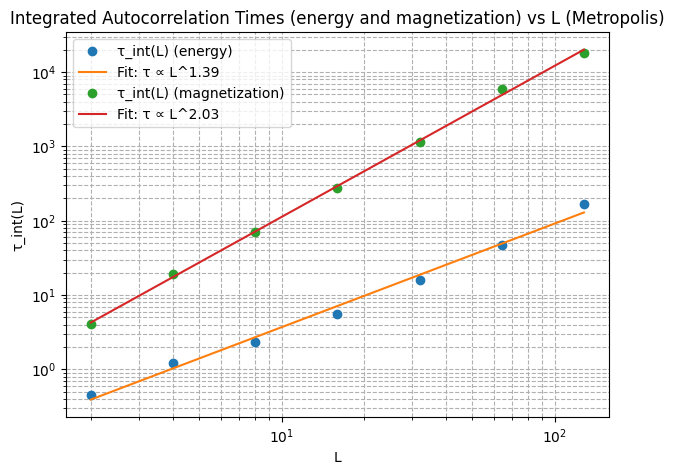

In [13]:
if len(tau_vs_L) < 2:
    print("Not enough valid points to perform the fit.")
else:
    tau_vs_L = np.array(tau_vs_L)
    Ls = tau_vs_L[1, :, 0]
    taus_eng = tau_vs_L[1, :, 1]
    taus_mag = tau_vs_L[0, :, 1]

    logL = np.log(Ls)
    logtau_eng = np.log(taus_eng)
    logtau_mag = np.log(taus_mag)

    slope_eng, intercept_eng, r_value_eng, p_value_eng, std_err_eng = linregress(logL, logtau_eng)
    z_eng = slope_eng
    slope_mag, intercept_mag, r_value_mag, p_value_mag, std_err_mag = linregress(logL, logtau_mag)
    z_mag = slope_mag

    print("\n======================================")
    print(f"Estimated Dynamical Critical Exponent for Energy: z = {z_eng:.3f}")
    print(f"R² coefficient = {r_value_eng**2:.4f}")
    print("======================================\n")

    print("\n======================================")
    print(f"Estimated Dynamical Critical Exponent for Magnetization: z = {z_mag:.3f}")
    print(f"R² coefficient = {r_value_mag**2:.4f}")
    print("======================================\n")

    plt.close('all')
    plt.figure(figsize=(7,5))
    plt.loglog(Ls, taus_eng, 'o', label="τ_int(L) (energy)")
    plt.loglog(Ls, np.exp(intercept_eng) * Ls**z_eng, label=f"Fit: τ ∝ L^{z_eng:.2f}")
    plt.loglog(Ls, taus_mag, 'o', label="τ_int(L) (magnetization)")
    plt.loglog(Ls, np.exp(intercept_mag) * Ls**z_mag, label=f"Fit: τ ∝ L^{z_mag:.2f}")
    plt.xlabel("L")
    plt.ylabel("τ_int(L)")
    plt.title("Integrated Autocorrelation Times (energy and magnetization) vs L (Metropolis)")
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.show()
